# 05 - Visualización Geoespacial

**Pregunta de negocio:** ¿Dónde operan nuestros vehículos?

## Objetivos
- Visualizar rutas en mapas interactivos con folium
- Crear heatmaps geográficos de actividad
- Comparar patrones urbanos vs carretera

## Teoría
- **folium**: genera mapas interactivos basados en Leaflet.js
- **HeatMap**: densidad de puntos GPS — zonas de alta actividad
- **PolyLine**: traza rutas conectando coordenadas

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import folium
from folium.plugins import HeatMap

plt.style.use('seaborn-v0_8-whitegrid')

project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
data_dir = os.path.join(project_root, "data/raw")

In [2]:
# Cargar primeros 3 días (rendimiento)
files = sorted(glob.glob(os.path.join(data_dir, "telemetry/telemetry_*.csv")))[:3]
telemetry = pd.concat([pd.read_csv(f, parse_dates=['timestamp']) for f in files], ignore_index=True)
fleet = pd.read_csv(os.path.join(data_dir, "fleet_profiles.csv"))
telemetry = telemetry.merge(fleet[['vehicle_id', 'vehicle_type']], on='vehicle_id', how='left')

print(f"Registros: {len(telemetry):,} (3 días)")
print(f"Vehículos: {telemetry['vehicle_id'].nunique()} | Viajes: {telemetry['trip_id'].nunique()}")

Registros: 585,849 (3 días)
Vehículos: 50 | Viajes: 316


## 1. Rutas de vehículos individuales

In [3]:
# Seleccionar 1 vehículo por tipo
center_lat = telemetry['gps_lat'].mean()
center_lon = telemetry['gps_lon'].mean()

m = folium.Map(location=[center_lat, center_lon], zoom_start=10, tiles='OpenStreetMap')

route_colors = {'electrico': 'green', 'gasolina': 'blue', 'hibrido': 'purple', 'deportivo': 'red'}

for vtype, color in route_colors.items():
    vids = telemetry[telemetry['vehicle_type'] == vtype]['vehicle_id'].unique()
    if len(vids) == 0:
        continue
    vid = vids[0]
    v_data = telemetry[telemetry['vehicle_id'] == vid]
    first_trip = v_data['trip_id'].unique()[0]
    trip = v_data[v_data['trip_id'] == first_trip]
    coords = trip[['gps_lat', 'gps_lon']].values[::10].tolist()
    
    if len(coords) > 1:
        folium.PolyLine(coords, color=color, weight=3, opacity=0.7,
                        tooltip=f"{vtype} ({vid[:8]}...)").add_to(m)
        folium.CircleMarker(coords[0], radius=6, color=color, fill=True,
                           popup=f"Inicio: {vtype}").add_to(m)
        folium.CircleMarker(coords[-1], radius=6, color=color, fill=True,
                           fill_opacity=0.3, popup=f"Fin: {vtype}").add_to(m)

print("Mapa de rutas (primer viaje por tipo):")
m

Mapa de rutas (primer viaje por tipo):


## 2. Heatmap de actividad vehicular

In [4]:
gps_sample = telemetry[['gps_lat', 'gps_lon']].iloc[::50].dropna()

m_heat = folium.Map(location=[center_lat, center_lon], zoom_start=9, tiles='CartoDB dark_matter')
HeatMap(gps_sample.values.tolist(), radius=15, blur=10, max_zoom=13,
        gradient={0.2: 'blue', 0.4: 'lime', 0.6: 'yellow', 0.8: 'orange', 1: 'red'}).add_to(m_heat)

print(f"Heatmap ({len(gps_sample):,} puntos):")
m_heat

Heatmap (11,717 puntos):


## 3. Rutas por tipo de vía

In [5]:
m_roads = folium.Map(location=[center_lat, center_lon], zoom_start=10)
road_colors = {'city': 'blue', 'highway': 'red', 'mixed': 'green'}

# Tomar un vehículo con varios viajes
sample_vid = telemetry['vehicle_id'].unique()[0]
v_trips = telemetry[telemetry['vehicle_id'] == sample_vid]

for trip_id in v_trips['trip_id'].unique()[:6]:
    trip = v_trips[v_trips['trip_id'] == trip_id]
    road = trip['road_type'].iloc[0]
    coords = trip[['gps_lat', 'gps_lon']].values[::10].tolist()
    if len(coords) > 1:
        folium.PolyLine(coords, color=road_colors.get(road, 'gray'),
                        weight=3, opacity=0.7, tooltip=f"{road}").add_to(m_roads)

legend_html = '''<div style="position: fixed; bottom: 30px; left: 30px; z-index: 1000;
     background: white; padding: 10px; border-radius: 5px; border: 2px solid grey;">
     <b>Tipo de vía</b><br>
     <span style="color:blue;">&#9632;</span> Ciudad<br>
     <span style="color:red;">&#9632;</span> Carretera<br>
     <span style="color:green;">&#9632;</span> Mixto</div>'''
m_roads.get_root().html.add_child(folium.Element(legend_html))

print(f"Rutas de {sample_vid[:8]}... por tipo de vía:")
m_roads

Rutas de 76dd4a81... por tipo de vía:


## 4. Estadísticas de viajes

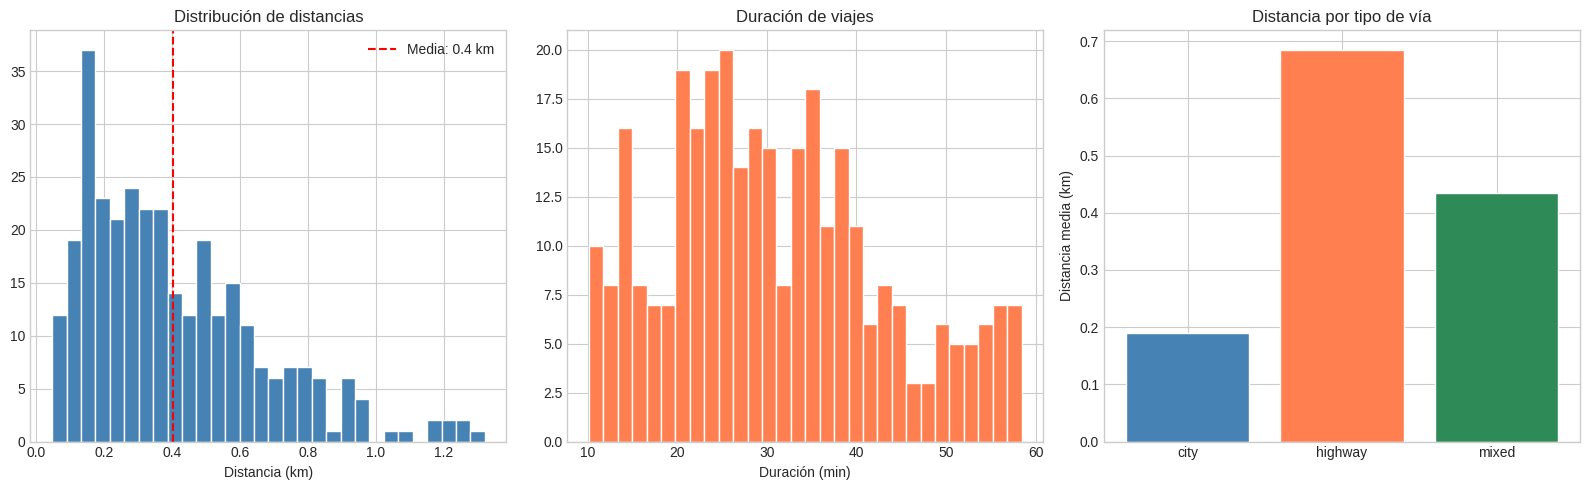

In [6]:
# Calcular distancias y duraciones
trip_ep = telemetry.groupby('trip_id').agg(
    start_lat=('gps_lat', 'first'), start_lon=('gps_lon', 'first'),
    end_lat=('gps_lat', 'last'), end_lon=('gps_lon', 'last'),
    road_type=('road_type', 'first'), duration_s=('speed_kmh', 'count'),
    speed_mean=('speed_kmh', 'mean'),
).reset_index()

dlat = np.radians(trip_ep['end_lat'] - trip_ep['start_lat'])
dlon = np.radians(trip_ep['end_lon'] - trip_ep['start_lon'])
trip_ep['distance_km'] = np.sqrt(dlat**2 + dlon**2) * 111

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(trip_ep['distance_km'], bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(trip_ep['distance_km'].mean(), color='red', linestyle='--',
                label=f'Media: {trip_ep["distance_km"].mean():.1f} km')
axes[0].set_xlabel('Distancia (km)')
axes[0].set_title('Distribución de distancias')
axes[0].legend()

axes[1].hist(trip_ep['duration_s'] / 60, bins=30, color='coral', edgecolor='white')
axes[1].set_xlabel('Duración (min)')
axes[1].set_title('Duración de viajes')

road_dist = trip_ep.groupby('road_type')['distance_km'].mean()
axes[2].bar(road_dist.index, road_dist.values,
            color=['steelblue', 'coral', 'seagreen'][:len(road_dist)], edgecolor='white')
axes[2].set_ylabel('Distancia media (km)')
axes[2].set_title('Distancia por tipo de vía')

plt.tight_layout()
plt.show()

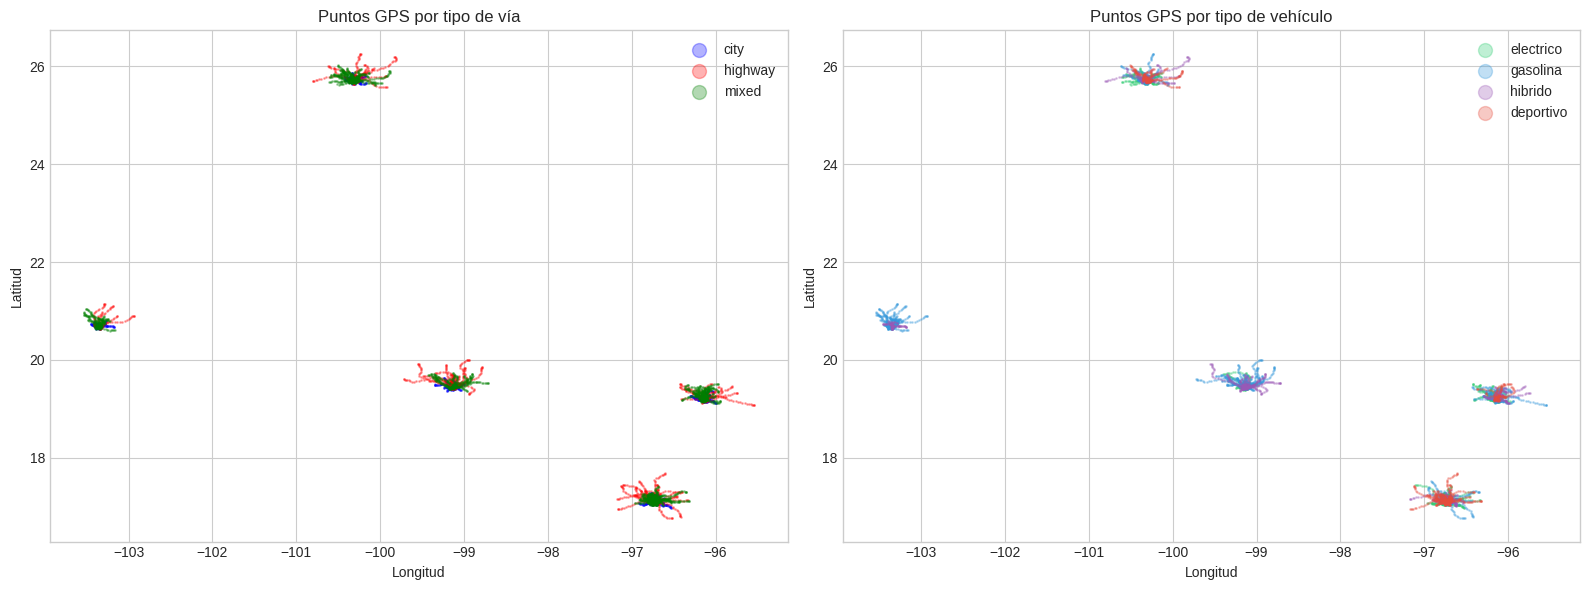

In [7]:
# Dispersión geográfica con matplotlib
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sample = telemetry.iloc[::100]

for road, color in road_colors.items():
    s = sample[sample['road_type'] == road]
    axes[0].scatter(s['gps_lon'], s['gps_lat'], s=1, alpha=0.3, color=color, label=road)
axes[0].set_xlabel('Longitud')
axes[0].set_ylabel('Latitud')
axes[0].set_title('Puntos GPS por tipo de vía')
axes[0].legend(markerscale=10)

vtype_c = {'electrico': '#2ecc71', 'gasolina': '#3498db', 'hibrido': '#9b59b6', 'deportivo': '#e74c3c'}
for vtype, color in vtype_c.items():
    s = sample[sample['vehicle_type'] == vtype]
    axes[1].scatter(s['gps_lon'], s['gps_lat'], s=1, alpha=0.3, color=color, label=vtype)
axes[1].set_xlabel('Longitud')
axes[1].set_ylabel('Latitud')
axes[1].set_title('Puntos GPS por tipo de vehículo')
axes[1].legend(markerscale=10)

plt.tight_layout()
plt.show()

## Resumen

> **¿Dónde operan nuestros vehículos?**
>
> La flota opera en las principales ciudades mexicanas. Los viajes urbanos son
> cortos y concentrados, los de carretera cubren mayor distancia.
> La visualización geoespacial permite optimizar ubicación de servicios.

### Siguiente:
→ `06_interactive_dashboard_plotly.ipynb`: Dashboard interactivo